In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model

In [6]:
# PyTorch
# class SpoofDetectionNet(nn.Module):
#     def __init__(self):
#         super(SpoofDetectionNet, self).__init__()
#         # CONV => RELU => CONV => RELU => POOL
#         self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding='same')
#         self.bn1 = nn.BatchNorm2d(16)
#         self.conv2 = nn.Conv2d(16, 16, kernel_size=3, padding='same')
#         self.bn2 = nn.BatchNorm2d(16)
#         self.pool1 = nn.MaxPool2d(kernel_size=2)
#         self.dropout1 = nn.Dropout(0.25)
# 
#         # CONV => RELU => CONV => RELU => POOL
#         self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
#         self.bn3 = nn.BatchNorm2d(32)
#         self.conv4 = nn.Conv2d(32, 32, kernel_size=3, padding='same')
#         self.bn4 = nn.BatchNorm2d(32)
#         self.pool2 = nn.MaxPool2d(kernel_size=2)
#         self.dropout2 = nn.Dropout(0.25)
# 
#         # FC => RELU
#         self.flatten = nn.Flatten()
#         self.fc1 = nn.Linear(32 * 16 * 16, 64)
#         self.bn5 = nn.BatchNorm1d(64)
#         self.dropout3 = nn.Dropout(0.5)
# 
#         # Warstwa wyjściowa
#         self.fc2 = nn.Linear(64, 2)
# 
#     def forward(self, x):
#         # CONV => RELU => CONV => RELU => POOL
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = F.relu(self.bn2(self.conv2(x)))
#         x = self.pool1(x)
#         x = self.dropout1(x)
# 
#         # CONV => RELU => CONV => RELU => POOL
#         x = F.relu(self.bn3(self.conv3(x)))
#         x = F.relu(self.bn4(self.conv4(x)))
#         x = self.pool2(x)
#         x = self.dropout2(x)
# 
#         # FC => RELU
#         x = self.flatten(x)
#         x = F.relu(self.bn5(self.fc1(x)))
#         x = self.dropout3(x)
# 
#         # Klasyfikator Softmax
#         x = self.fc2(x)
#         return F.log_softmax(x, dim=1)

In [7]:
def SpoofDetectionNet(input_shape=(64, 64, 3)):
    # Input layer
    inputs = tf.keras.Input(shape=input_shape)

    # First conv block: CONV => RELU => CONV => RELU => POOL => DROPOUT
    x = layers.Conv2D(16, kernel_size=3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(16, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Second conv block: CONV => RELU => CONV => RELU => POOL => DROPOUT
    x = layers.Conv2D(32, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(32, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Flatten the output of the conv layers
    x = layers.Flatten()(x)

    # Fully connected layer with batch normalization and dropout
    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.5)(x)

    # Output layer (2 classes)
    outputs = layers.Dense(2, activation='softmax')(x)

    # Create the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    return model

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 541,778 (2.07 MB)

 Trainable params: 541,458 (2.07 MB)

 Non-trainable params: 320 (1.25 KB)

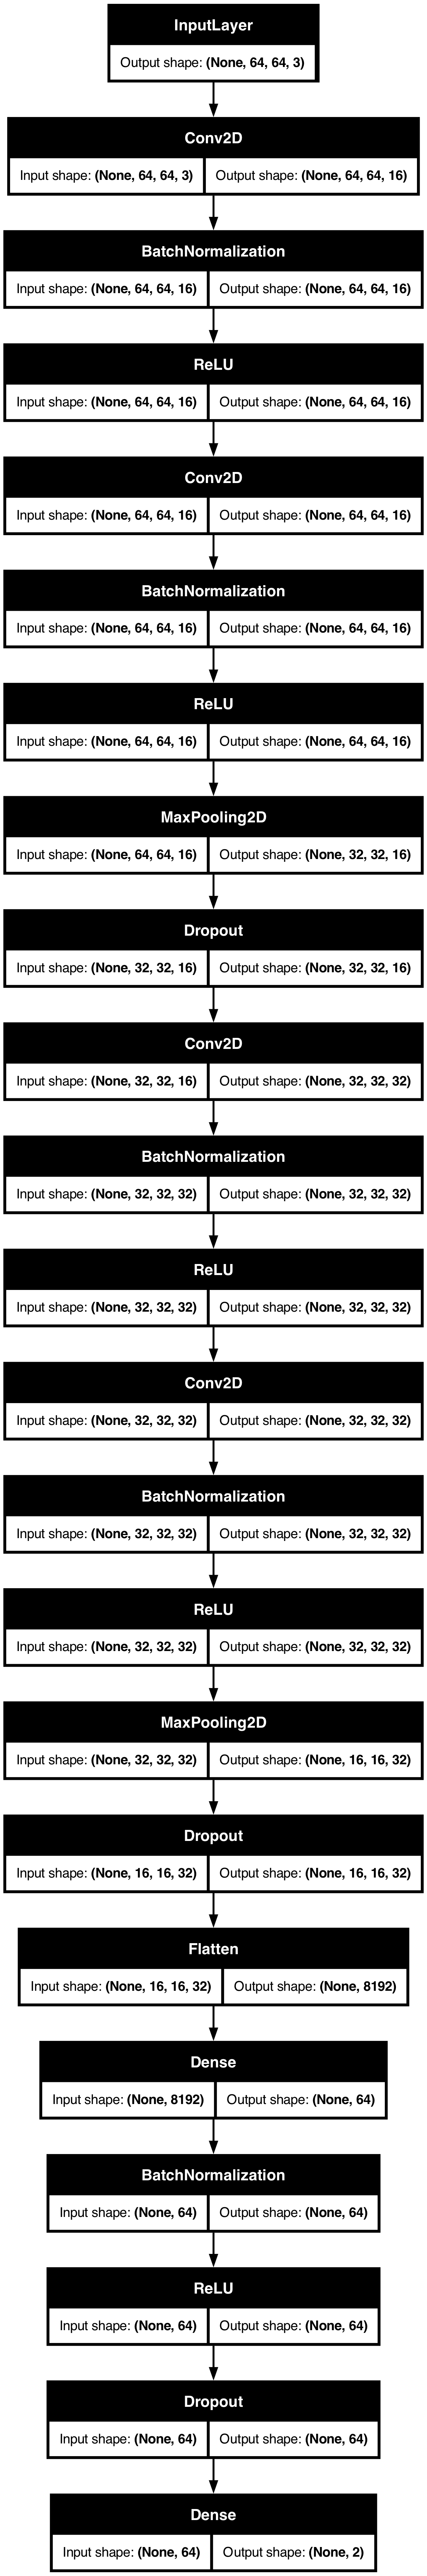

In [8]:
# Build the model using the functional API
model = SpoofDetectionNet()

# Print the model summary
model.summary()

# Visualize the model architecture
plot_model(model, to_file='spoof_detection_net_functional.png', show_shapes=True)